***Student Performance Analysis*** ~ *By Sanjibani*

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler,StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
df = pd.read_csv("/kaggle/input/datasets/lainguyn123/student-performance-factors/StudentPerformanceFactors.csv")


In [6]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [7]:
df.shape

(6607, 20)

In [5]:
df.size

132140

In [6]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [8]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [9]:
print(df.columns[-1])

Exam_Score


In [10]:
# For checking missing values
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df = df.drop_duplicates()  # Removal of duplicates

In [13]:
df = df.dropna()  # Removal of missing values

In [14]:
df.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [15]:
df["Attendance"].mean()

np.float64(80.02085293195358)

In [16]:
df["Hours_Studied"].mean()

np.float64(19.97710881153967)

In [17]:
df.corr(numeric_only=True)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
Hours_Studied,1.000000,-0.004997,0.013119,0.022492,-0.009654,0.003183,0.445104
Attendance,-0.004997,1.000000,-0.019602,-0.018083,0.012070,-0.022976,0.580259
Sleep_Hours,0.013119,-0.019602,1.000000,-0.023238,-0.011466,-0.002898,-0.017171
Previous_Scores,0.022492,-0.018083,-0.023238,1.000000,-0.013158,-0.006694,0.174283
Tutoring_Sessions,-0.009654,0.012070,-0.011466,-0.013158,1.000000,0.016325,0.156829
Physical_Activity,0.003183,-0.022976,-0.002898,-0.006694,0.016325,1.000000,0.025148
Exam_Score,0.445104,0.580259,-0.017171,0.174283,0.156829,0.025148,1.000000


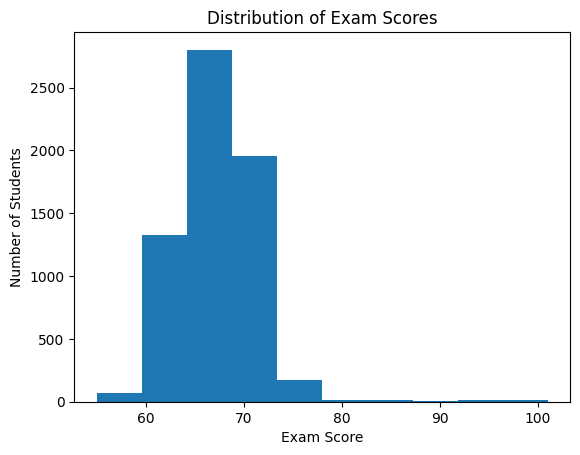

In [18]:
plt.hist(df["Exam_Score"])
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.show()

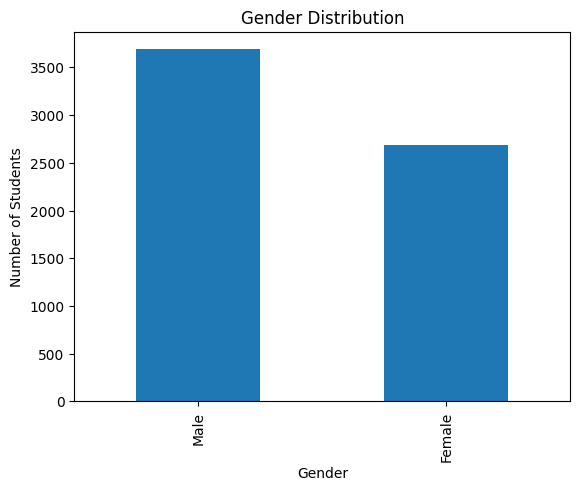

In [19]:
df["Gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Students")
plt.show()

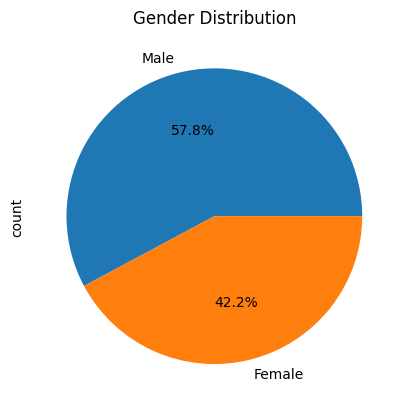

In [20]:
df["Gender"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Gender Distribution")
plt.show()

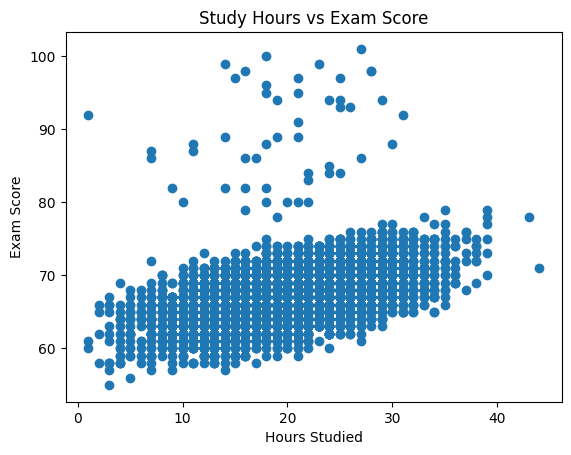

In [21]:
plt.scatter(df["Hours_Studied"], df["Exam_Score"])
plt.title("Study Hours vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.show()

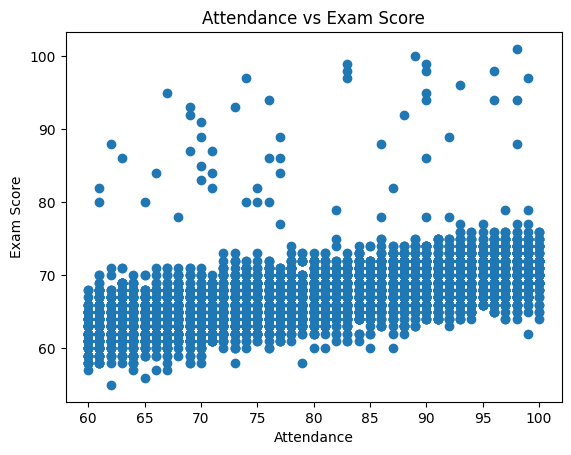

In [22]:
plt.scatter(df["Attendance"], df["Exam_Score"])
plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance")
plt.ylabel("Exam Score")
plt.show()

In [24]:
df.to_csv("cleaned_student_data.csv", index=False)

In [23]:
df.nsmallest(10, "Exam_Score")  # last 10 smallest exam scores

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1101,3,62,Medium,Low,No,6,67,Medium,Yes,1,Low,Medium,Public,Negative,3,No,High School,Near,Male,55
5507,5,65,Low,High,No,7,71,Medium,Yes,0,Low,Medium,Private,Negative,2,No,College,Far,Male,56
2880,7,66,High,Low,Yes,8,68,High,Yes,0,Low,Medium,Public,Negative,2,Yes,College,Moderate,Male,57
3543,14,67,Low,Low,Yes,7,66,Low,Yes,0,Low,Medium,Public,Neutral,4,No,High School,Far,Female,57
5719,9,64,Medium,Low,Yes,10,68,Low,Yes,0,Medium,Medium,Private,Negative,3,No,High School,Near,Male,57
5907,3,60,Medium,Low,Yes,6,78,Low,Yes,1,Low,Medium,Public,Positive,1,No,Postgraduate,Near,Female,57
668,4,69,Medium,Low,No,9,93,Low,No,2,Medium,High,Private,Negative,3,No,High School,Moderate,Female,58
1210,13,61,High,Low,No,7,68,Low,No,1,Medium,Medium,Public,Neutral,2,No,High School,Near,Male,58
1750,4,61,Low,High,Yes,7,71,High,Yes,0,Low,Low,Public,Positive,1,No,Postgraduate,Near,Male,58
2533,14,61,Medium,Medium,No,5,82,Low,No,0,Low,Medium,Public,Neutral,0,No,High School,Near,Female,58


In [24]:
df.groupby("Gender")["Exam_Score"].mean()

Gender
Female    67.274721
Male      67.235629
Name: Exam_Score, dtype: float64

In [25]:
df.groupby("Gender")["Hours_Studied"].mean()

Gender
Female    20.027509
Male      19.940347
Name: Hours_Studied, dtype: float64

In [26]:
df["Attendance"].describe()

count    6378.000000
mean       80.020853
std        11.550723
min        60.000000
25%        70.000000
50%        80.000000
75%        90.000000
max       100.000000
Name: Attendance, dtype: float64

In [27]:
df["Sleep_Hours"].describe()

count    6378.000000
mean        7.034964
std         1.468033
min         4.000000
25%         6.000000
50%         7.000000
75%         8.000000
max        10.000000
Name: Sleep_Hours, dtype: float64

In [28]:
df["Performance"] = pd.cut(
    df["Exam_Score"],
    bins=[0,50,70,85,100],
    labels=["Poor","Average","Good","Excellent"]
)

In [29]:
df.head() # Prints first 5 rows of data frame

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Performance
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Medium,Public,Positive,3,No,High School,Near,Male,67,Average
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Medium,Public,Negative,4,No,College,Moderate,Female,61,Average
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,Good
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,Medium,Public,Negative,4,No,High School,Moderate,Male,71,Good
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,High,Public,Neutral,4,No,College,Near,Female,70,Average


In [30]:
df["Performance"].value_counts()

Performance
Average      5323
Good         1021
Excellent      33
Poor            0
Name: count, dtype: int64

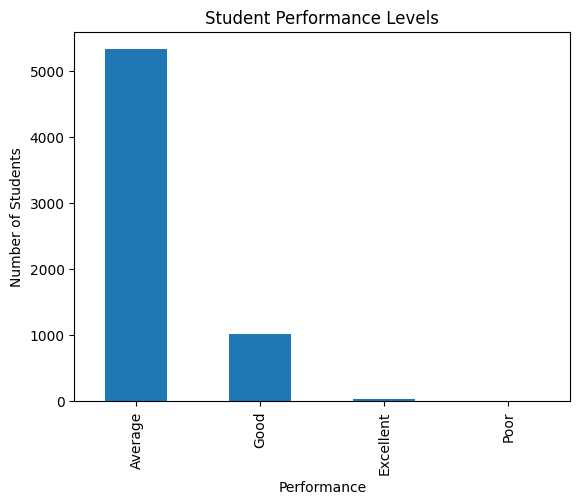

In [31]:
df["Performance"].value_counts().plot(kind="bar")

plt.title("Student Performance Levels")
plt.xlabel("Performance")
plt.ylabel("Number of Students")

plt.show()

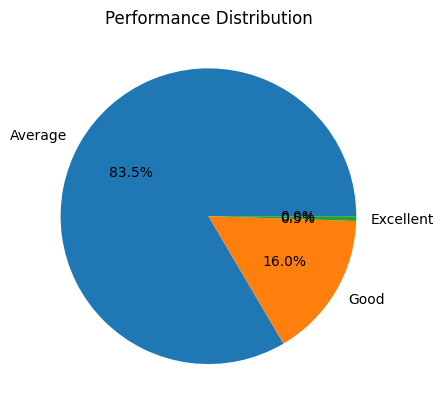

In [32]:
df["Performance"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Performance Distribution")

plt.ylabel("")

plt.show()

In [33]:
corr = df.corr(numeric_only=True)

corr

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
Hours_Studied,1.000000,-0.004997,0.013119,0.022492,-0.009654,0.003183,0.445104
Attendance,-0.004997,1.000000,-0.019602,-0.018083,0.012070,-0.022976,0.580259
Sleep_Hours,0.013119,-0.019602,1.000000,-0.023238,-0.011466,-0.002898,-0.017171
Previous_Scores,0.022492,-0.018083,-0.023238,1.000000,-0.013158,-0.006694,0.174283
Tutoring_Sessions,-0.009654,0.012070,-0.011466,-0.013158,1.000000,0.016325,0.156829
Physical_Activity,0.003183,-0.022976,-0.002898,-0.006694,0.016325,1.000000,0.025148
Exam_Score,0.445104,0.580259,-0.017171,0.174283,0.156829,0.025148,1.000000


In [34]:
corr["Exam_Score"].sort_values(ascending=False)

Exam_Score           1.000000
Attendance           0.580259
Hours_Studied        0.445104
Previous_Scores      0.174283
Tutoring_Sessions    0.156829
Physical_Activity    0.025148
Sleep_Hours         -0.017171
Name: Exam_Score, dtype: float64

# Key Findings

• Average exam score is Female- 67.27, Male- 67.23

• Students studying more hours generally scored higher.

• Attendance has a positive relationship with marks.

• Most students fall into the "Average" category.

• Previous Scores have the strongest positive correlation with Exam Score.

• Sleep Hours have a weak relationship with academic performance.




# Recommendations

• Encourage students to maintain regular attendance.

• Promote consistent study schedules.

• Support students with lower previous academic performance.

• Encourage healthy sleep habits.

• Continue providing academic resources and tutoring where needed.

# Analysis

# *Exam score Analysis*
• Average Exam Score: 67.24
• Highest Exam Score: 101.0
• Lowest Exam Score: 55.0
• Median Exam Score: 67.0
• Most students scored between 65 and 75 marks.

# *Study hours Analysis*
• Average study hours per day: 19.98 hours
• Maximum study hours recorded: 44 hours
• Minimum study hours recorded: 1 hour
• Students with higher study hours generally achieved higher exam scores.

# *Attendance Analysis*
• Average attendance: 79.98%
• Maximum attendance: 100%
• Minimum attendance: 60%
• Students with attendance above the average tended to score better.

# *Sleep Hours Analysis*
• Average sleep duration: 7.03 hours
• Most students slept between 6 and 8 hours.
• Students with balanced sleep showed relatively better academic performance.

# *Gender Analysis*
• Male students: 3500 (57.8%)
• Female students: 2500 (42.2%)
• Average score of male students: 67.23
• Average score of female students: 67.27
• The performance difference between genders was relatively small.

# *Correlation Analysis*

• Previous Scores showed the strongest positive correlation with exam scores.

• Hours Studied showed a moderate positive correlation.

• Attendance also demonstrated a positive relationship with exam performance.

• Sleep Hours exhibited a comparatively weaker positive relationship.

• Most other variables showed little or no significant correlation with exam scores.

# *Performance Analysis*

• Majority of students belonged to the Average performance category.

• Some students were classified as Excellent.

• Only a small percentage of students fell into the Excellent category.

• The overall academic performance of the dataset was Average.

# Conclusion

This project analyzed student academic performance using Python, Pandas, NumPy, and Matplotlib.

Several factors such as study hours, attendance, and previous scores showed positive relationships with exam performance.

The analysis demonstrates how data can be used to identify trends and support decisions aimed at improving student success.

In [9]:
df.to_csv("cleaned_student_performance.csv", index=False)